#**TASK1**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces


In [2]:
# ==============================================================================
# Task 1.1 — Build the MDP
# ==============================================================================
def build_mdp():
    """
    Builds the Markov Decision Process by defining the Transition Matrix (P)
    and the Expected Immediate Rewards Matrix (R).
    """
    # STATES  -> 0: High, 1: Low, 2: Charging
    # ACTIONS -> 0: Search, 1: Wait

    # Initialize 3D P matrix (State, Action, Next_State) and 2D R matrix (State, Action)
    P = np.zeros((3, 2, 3))
    R = np.zeros((3, 2))

    # --- Populate Transition Probabilities P(s' | s, a) ---
    P[0, 0, 0] = 0.7  # High -> Search -> High
    P[0, 0, 1] = 0.3  # High -> Search -> Low
    P[0, 1, 0] = 1.0  # High -> Wait -> High

    P[1, 0, 0] = 0.4  # Low -> Search -> High
    P[1, 0, 1] = 0.6  # Low -> Search -> Low
    P[1, 1, 1] = 1.0  # Low -> Wait -> Low

    P[2, 1, 0] = 1.0  # Charging -> Wait -> High
    P[2, 0, 2] = 1.0  # Dummy fallback to ensure valid probabilities for unused state-action pair

    # --- Populate Immediate Rewards R(s, a) ---
    # Expected reward = sum of (Probability of next state * Reward of transition)
    R[0, 0] = (0.7 * 4) + (0.3 * 4)       # High, Search
    R[0, 1] = (1.0 * 1)                   # High, Wait
    R[1, 0] = (0.4 * -3) + (0.6 * 4)      # Low, Search
    R[1, 1] = (1.0 * 1)                   # Low, Wait
    R[2, 1] = (1.0 * 0)                   # Charging, Wait

    # Verify setup by printing the sums of probabilities (must equal 1.0)
    print("--- Task 1.1: Verification ---")
    for s in range(3):
        for a in range(2):
            print(f"Sum of P[state={s}, action={a}, :] = {np.sum(P[s, a, :])}")

    print("\nFull R array (Expected immediate rewards):")
    print(R)

    return P, R


In [3]:

# ==============================================================================
# Task 1.2 — Implement policy_evaluation()
# ==============================================================================
def policy_evaluation(P, R, policy, gamma=0.9, theta=1e-6):
    """
    Evaluates a fixed policy by sweeping through state spaces using the
    Bellman Expectation update until changes drop below a given threshold.
    """
    V = np.zeros(3)  # Initialise V(s) = 0 for all states
    iterations = 0

    while True:
        delta = 0
        V_new = np.zeros(3)

        # Iterate over all states to apply the Bellman update
        for s in range(3):
            a = policy[s] # The action dictated by our fixed policy

            # Calculate the expected future value using transition probabilities
            expected_future_value = np.sum(P[s, a, :] * V)

            # Bellman Expectation Equation Update
            V_new[s] = R[s, a] + gamma * expected_future_value

            # Track the maximum change across all states for convergence checking
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new
        iterations += 1

        # Stop sweeping if the largest change is smaller than the threshold
        if delta < theta:
            break

    print("\n--- Task 1.2: Policy Evaluation ---")
    print(f"Number of iterations taken to converge: {iterations}")
    print(f"Converged V values: {V}")

    return V


In [4]:
# ==============================================================================
# Task 1.3 — Plot
# ==============================================================================
def plot_values(V):
    """
    Generates a properly labelled bar chart of the converged state values.
    """
    states = ['High', 'Low', 'Charging']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(states, V, color=['skyblue', 'lightcoral', 'lightgreen'])

    # Add accurate titles and labels
    plt.title('Expected Cumulative Rewards by Starting State V(s)')
    plt.xlabel('Initial Battery State')
    plt.ylabel('Expected Discounted Reward V(s)')

    # Set y-axis limit slightly higher for visual padding
    plt.ylim(0, max(V) + 5)

    # Display the exact numeric values on top of each bar for clarity
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.3, round(yval, 2), ha='center', va='bottom')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # The plot is rendered at the end of the script using plt.show()

--- Task 1.1: Verification ---
Sum of P[state=0, action=0, :] = 1.0
Sum of P[state=0, action=1, :] = 1.0
Sum of P[state=1, action=0, :] = 1.0
Sum of P[state=1, action=1, :] = 1.0
Sum of P[state=2, action=0, :] = 1.0
Sum of P[state=2, action=1, :] = 1.0

Full R array (Expected immediate rewards):
[[4.  1. ]
 [1.2 1. ]
 [0.  0. ]]

--- Task 1.2: Policy Evaluation ---
Number of iterations taken to converge: 133
Converged V values: [18.1080999   9.99999179 16.29728909]

--- Bonus: Gymnasium Empirical Evaluation ---
Empirical V values (Averaged over 5000 episodes): [18.08513312  9.99973439 16.31233238]


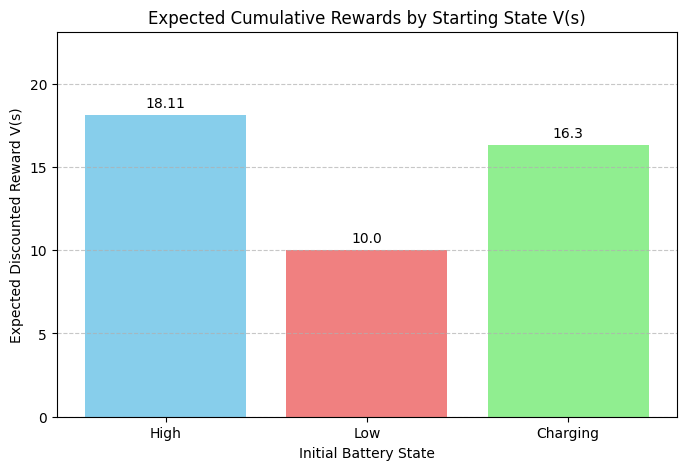

In [5]:
# ==============================================================================
# Bonus — Gymnasium Implementation
# ==============================================================================
class RobotBatteryEnv(gym.Env):
    """
    Custom Gymnasium Environment simulating the defined MDP dynamics.
    """
    def __init__(self, P, R):
        super().__init__()
        self.P = P
        self.R = R
        self.action_space = spaces.Discrete(2)       # 2 possible actions
        self.observation_space = spaces.Discrete(3)  # 3 possible states
        self.state = 0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = 0  # Standard default start
        return self.state, {}

    def step(self, action):
        # Stochastically select the next state based on the P matrix
        probs = self.P[self.state, action]
        next_state = np.random.choice([0, 1, 2], p=probs)

        # Look up the immediate reward based on the R matrix
        reward = self.R[self.state, action]

        self.state = next_state

        # The environment runs continuously, so it never naturally terminates
        terminated = False
        truncated = False

        return self.state, reward, terminated, truncated, {}

def simulate_gymnasium(P, R, policy, gamma=0.9, episodes=5000, max_steps=100):
    """
    Runs repeated episodes in the Gym environment to empirically estimate
    state values and compare them against the analytical solution.
    """
    env = RobotBatteryEnv(P, R)
    empirical_V = np.zeros(3)

    # Test starting from each individual state
    for start_state in range(3):
        total_returns = 0

        # Run multiple episodes to get an accurate average
        for _ in range(episodes):
            env.state = start_state
            state = start_state
            episode_return = 0
            discount = 1.0

            # Step through the environment using the fixed policy
            for _ in range(max_steps):
                action = policy[state]
                next_state, reward, _, _, _ = env.step(action)

                episode_return += discount * reward
                discount *= gamma
                state = next_state

            total_returns += episode_return

        # Calculate the average return across all episodes for this starting state
        empirical_V[start_state] = total_returns / episodes

    print("\n--- Bonus: Gymnasium Empirical Evaluation ---")
    print(f"Empirical V values (Averaged over {episodes} episodes): {empirical_V}")
    return empirical_V

# ==============================================================================
# Main Execution Block
# ==============================================================================
if __name__ == "__main__":
    # Task 1.1: Build the model
    P_matrix, R_matrix = build_mdp()

    # Task 1.2: Evaluate Policy [High: Search(0), Low: Wait(1), Charging: Wait(1)]
    eval_policy = [0, 1, 1]
    V_analytical = policy_evaluation(P_matrix, R_matrix, eval_policy)

    # Task 1.3: Plot the analytical results
    plot_values(V_analytical)

    # Bonus: Compare exact mathematical values with Gym simulation
    V_empirical = simulate_gymnasium(P_matrix, R_matrix, eval_policy)

    # Render the chart created in Task 1.3
    plt.show()

**TASK 2**


--- Task 2.1: Value Iteration ---
Converged in 142 iterations.
Optimal V* values: [29.64382671 25.80821027 26.67944315]

--- Task 2.2: Extract Optimal Policy ---
Optimal Policy for High: Search (Index 0)
Optimal Policy for Low: Search (Index 0)
Optimal Policy for Charging: Wait (Index 1)


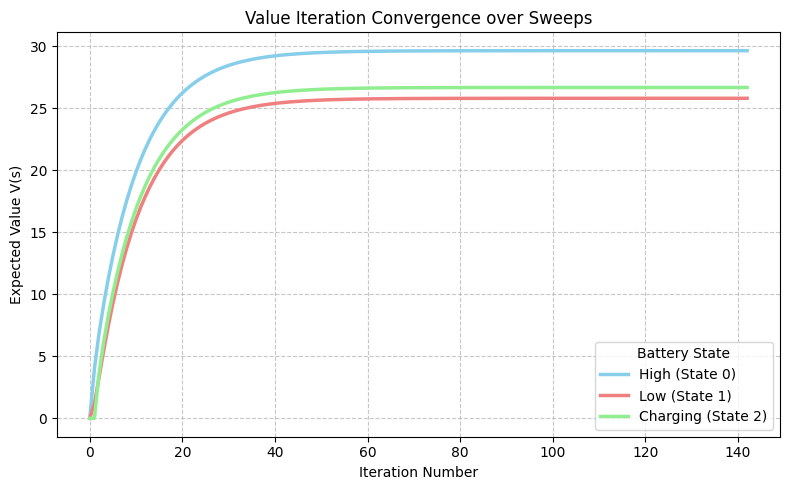

In [6]:
# ==============================================================================
# Task 2.1 — Implement value_iteration()
# ==============================================================================
def value_iteration(P, R, gamma=0.9, theta=1e-6):
    """
    Computes the optimal value function V* directly by repeatedly applying the
    Bellman Optimality update until convergence.
    """
    V = np.zeros(3)  # Initialise V(s) = 0 for all states
    history = [V.copy()]  # Store initial V values
    iterations = 0

    while True:
        delta = 0
        V_new = np.zeros(3)

        # Sweep through all states
        for s in range(3):
            Q_s = np.zeros(2) # To store Q(s,a) for both actions

            # Compute Q(s, a) for every (state, action) pair
            for a in range(2):
                expected_future_value = np.sum(P[s, a, :] * V)
                Q_s[a] = R[s, a] + gamma * expected_future_value

            # Set V(s) = max over actions of Q(s, a)
            V_new[s] = np.max(Q_s)

            # Track the maximum change across all states
            delta = max(delta, abs(V_new[s] - V[s]))

        V = V_new.copy()
        history.append(V.copy()) # Store V after every iteration for plotting
        iterations += 1

        # Stop when max change across all states is less than theta
        if delta < theta:
            break

    print("\n--- Task 2.1: Value Iteration ---")
    print(f"Converged in {iterations} iterations.")
    print(f"Optimal V* values: {V}")

    return V, history

# ==============================================================================
# Task 2.2 — Extract the Optimal Policy
# ==============================================================================
def extract_policy(V_star, P, R, gamma=0.9):
    """
    Extracts the optimal policy by acting greedily with respect to the
    converged optimal value function V*.
    """
    optimal_policy = np.zeros(3, dtype=int)

    # For each state, compute Q(s, a) using the optimal V*
    for s in range(3):
        Q_s = np.zeros(2)

        for a in range(2):
            expected_future_value = np.sum(P[s, a, :] * V_star)
            Q_s[a] = R[s, a] + gamma * expected_future_value

        # Return the action index with the highest Q value
        optimal_policy[s] = np.argmax(Q_s)

    print("\n--- Task 2.2: Extract Optimal Policy ---")
    actions = ['Search', 'Wait']
    states = ['High', 'Low', 'Charging']

    for s in range(3):
        print(f"Optimal Policy for {states[s]}: {actions[optimal_policy[s]]} (Index {optimal_policy[s]})")

    return optimal_policy

# ==============================================================================
# Task 2.3 — Plot Convergence
# ==============================================================================
def plot_convergence(history):
    """
    Plots the convergence of V(s) across sweeps/iterations on a single graph.
    """
    # Convert history list to a 2D numpy array for easy column slicing
    history_array = np.array(history)

    plt.figure(figsize=(8, 5))

    # Plot one line per state
    plt.plot(history_array[:, 0], label='High (State 0)', color='skyblue', linewidth=2.5)
    plt.plot(history_array[:, 1], label='Low (State 1)', color='lightcoral', linewidth=2.5)
    plt.plot(history_array[:, 2], label='Charging (State 2)', color='lightgreen', linewidth=2.5)

    plt.title('Value Iteration Convergence over Sweeps')
    plt.xlabel('Iteration Number')
    plt.ylabel('Expected Value V(s)')
    plt.legend(title='Battery State')
    plt.grid(axis='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution Block
# ==============================================================================
if __name__ == "__main__":
    # Briefly recreating P and R from Task 1 so this script runs standalone
    P_matrix = np.zeros((3, 2, 3))
    R_matrix = np.zeros((3, 2))

    P_matrix[0, 0, 0] = 0.7; P_matrix[0, 0, 1] = 0.3; P_matrix[0, 1, 0] = 1.0
    P_matrix[1, 0, 0] = 0.4; P_matrix[1, 0, 1] = 0.6; P_matrix[1, 1, 1] = 1.0
    P_matrix[2, 1, 0] = 1.0; P_matrix[2, 0, 2] = 1.0

    R_matrix[0, 0] = (0.7 * 4) + (0.3 * 4); R_matrix[0, 1] = 1.0
    R_matrix[1, 0] = (0.4 * -3) + (0.6 * 4); R_matrix[1, 1] = 1.0
    R_matrix[2, 1] = 0.0

    # Execute Task 2.1
    V_optimal, convergence_history = value_iteration(P_matrix, R_matrix)

    # Execute Task 2.2
    optimal_pi = extract_policy(V_optimal, P_matrix, R_matrix)

    # Execute Task 2.3
    plot_convergence(convergence_history)

**TASK 3**


--- Task 3.2: Policy Iteration Trace ---
Iteration 0:
  Policy: [1 1 1]
  V vals: [10. 10.  9.]
Iteration 1:
  Policy: [0 0 1]
  V vals: [29.644 25.808 26.679]
=> Policy is stable. Convergence achieved.

--- Final Results ---
Optimal Policy pi*: [0 0 1]
Optimal Values V*: [29.64 25.81 26.68]


/tmp/ipykernel_9783/654786771.py:125: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Pastel2', 2) # Two discrete colors for Search/Wait


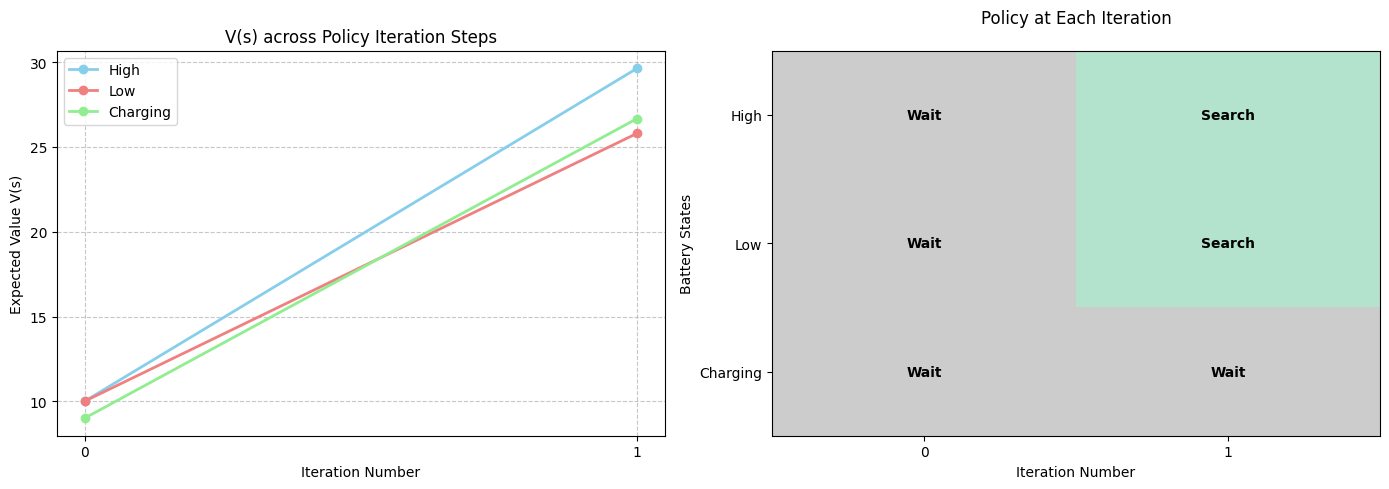

In [7]:
# ==============================================================================
# Helper functions from Task 1 (Needed for Policy Iteration)
# ==============================================================================
def policy_evaluation(P, R, policy, gamma=0.9, theta=1e-6):
    """
    Evaluates a fixed policy and returns the converged state-value function V.
    """
    V = np.zeros(3)
    while True:
        delta = 0
        V_new = np.zeros(3)
        for s in range(3):
            a = policy[s]
            # Bellman Expectation Update
            V_new[s] = R[s, a] + gamma * np.sum(P[s, a, :] * V)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new.copy()
        if delta < theta:
            break
    return V

# ==============================================================================
# Task 3.1 — Implement policy_improvement()
# ==============================================================================
def policy_improvement(V, P, R, current_policy, gamma=0.9):
    """
    Updates the policy greedily using the computed V.
    Returns the new_policy and a boolean indicating if the policy stabilized.
    """
    new_policy = np.zeros(3, dtype=int)
    stable = True

    # Evaluate the Q-values for all state-action pairs
    for s in range(3):
        Q_s = np.zeros(2)

        for a in range(2):
            # EXPLICIT CONSTRAINT: Action 'Search' (0) is NOT allowed in 'Charging' state (2)
            if s == 2 and a == 0:
                Q_s[a] = -np.inf  # Assign negative infinity so it is never chosen greedily
                continue

            expected_future_value = np.sum(P[s, a, :] * V)
            Q_s[a] = R[s, a] + gamma * expected_future_value

        # Select the greedy action
        best_action = np.argmax(Q_s)
        new_policy[s] = best_action

        # Check if the chosen action is different from the old policy
        if best_action != current_policy[s]:
            stable = False

    return new_policy, stable

# ==============================================================================
# Task 3.2 — Implement Full policy_iteration() Loop
# ==============================================================================
def policy_iteration(P, R, gamma=0.9, theta=1e-6):
    """
    Alternates between evaluating the current policy and improving it until
    the policy stops changing (converges to optimal).
    """
    # Initialize all states to take action 1 ('Wait')
    current_policy = np.array([1, 1, 1], dtype=int)

    # Histories for plotting
    V_history = []
    policy_history = []

    iteration = 0
    print("\n--- Task 3.2: Policy Iteration Trace ---")

    while True:
        # 1. Store current policy
        policy_history.append(current_policy.copy())

        # 2. Policy Evaluation: compute V for current policy
        V = policy_evaluation(P, R, current_policy, gamma, theta)
        V_history.append(V.copy())

        print(f"Iteration {iteration}:")
        print(f"  Policy: {current_policy}")
        print(f"  V vals: {np.round(V, 3)}")

        # 3. Policy Improvement: get a new greedy policy
        new_policy, stable = policy_improvement(V, P, R, current_policy, gamma)

        # 4. Stop when policy did not change
        if stable:
            print("=> Policy is stable. Convergence achieved.")
            break

        current_policy = new_policy.copy()
        iteration += 1

    return current_policy, V, V_history, policy_history

# ==============================================================================
# Task 3.3 — Plot Results
# ==============================================================================
def plot_results(V_history, policy_history):
    """
    Generates a line plot for V(s) convergence and a heatmap for policy changes.
    """
    V_arr = np.array(V_history)
    pol_arr = np.array(policy_history).T # Transpose to shape (states, iterations)

    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    iterations = range(len(V_history))

    # --- (a) Line plot for V(s) ---
    ax[0].plot(iterations, V_arr[:, 0], label='High', color='skyblue', marker='o', lw=2)
    ax[0].plot(iterations, V_arr[:, 1], label='Low', color='lightcoral', marker='o', lw=2)
    ax[0].plot(iterations, V_arr[:, 2], label='Charging', color='lightgreen', marker='o', lw=2)
    ax[0].set_title("V(s) across Policy Iteration Steps")
    ax[0].set_xlabel("Iteration Number")
    ax[0].set_ylabel("Expected Value V(s)")
    ax[0].set_xticks(iterations)
    ax[0].legend()
    ax[0].grid(True, linestyle='--', alpha=0.7)

    # --- (b) Heatmap/Table for Policy ---
    # Using a standard matplotlib matrix show (matshow)
    cmap = plt.cm.get_cmap('Pastel2', 2) # Two discrete colors for Search/Wait
    cax = ax[1].matshow(pol_arr, cmap=cmap, vmin=0, vmax=1, aspect='auto')

    ax[1].set_title("Policy at Each Iteration", pad=20)
    ax[1].set_xlabel("Iteration Number")
    ax[1].set_ylabel("Battery States")

    # Configure axes labels
    ax[1].set_xticks(iterations)
    ax[1].set_yticks([0, 1, 2])
    ax[1].set_yticklabels(['High', 'Low', 'Charging'])
    ax[1].xaxis.set_ticks_position('bottom')

    # Overlay the action text directly onto the cells
    action_names = {0: 'Search', 1: 'Wait'}
    for i in range(3):
        for j in range(len(policy_history)):
            action_idx = pol_arr[i, j]
            ax[1].text(j, i, action_names[action_idx], ha='center', va='center',
                       color='black', fontweight='bold')

    plt.tight_layout()
    plt.show()

# ==============================================================================
# Execution Block
# ==============================================================================
if __name__ == "__main__":
    # Standard MDP Setup from Assignment
    P_matrix = np.zeros((3, 2, 3))
    R_matrix = np.zeros((3, 2))

    # Populate P and R (as defined in Task 1 table)
    P_matrix[0, 0, 0] = 0.7; P_matrix[0, 0, 1] = 0.3; P_matrix[0, 1, 0] = 1.0
    P_matrix[1, 0, 0] = 0.4; P_matrix[1, 0, 1] = 0.6; P_matrix[1, 1, 1] = 1.0
    P_matrix[2, 1, 0] = 1.0;

    # Rewards: R = sum( P * reward )
    R_matrix[0, 0] = (0.7 * 4) + (0.3 * 4); R_matrix[0, 1] = 1.0
    R_matrix[1, 0] = (0.4 * -3) + (0.6 * 4); R_matrix[1, 1] = 1.0
    R_matrix[2, 1] = 0.0

    # Run full Policy Iteration
    opt_policy, opt_V, V_hist, pol_hist = policy_iteration(P_matrix, R_matrix)

    print("\n--- Final Results ---")
    print(f"Optimal Policy pi*: {opt_policy}")
    print(f"Optimal Values V*: {np.round(opt_V, 2)}")

    # Generate the requested plots
    plot_results(V_hist, pol_hist)

**TASK 4**

4.1 Algorithm Comparison
Policy Iteration converged in far fewer outer steps (essentially 1 major update) compared to Value Iteration (142 sweeps). This happens because Policy Iteration completely flattens out the math for a specific rule before making a massive, highly accurate leap to a better rule. Value Iteration takes many tiny, incremental steps because it continuously shifts its assumptions about the best action while updating the values simultaneously.

4.2 Convergence Behavior
In Value Iteration, the V(s) curves rise smoothly and level off as the discounted future rewards heavily impact the early steps but taper off as they project further into the future. The fundamental difference lies in the equations: Value Iteration actively selects the "max" action at every micro-step to force optimality, whereas Policy Evaluation simply computes the weighted average of a fixed, predetermined path.

4.3 Optimal Policy Interpretation
The algorithms mathematically proved that the optimal strategy is: Search when High, Search when Low, and Wait when Charging.
While "Wait on Low" seems intuitively safer to avoid the -3 recharge penalty, the math reveals that with a discount factor of 0.9, the risk is worth it. The consistent +4 reward from searching heavily outweighs the occasional -3 penalty, especially because the penalty state immediately resets the robot back to a High battery where it can continue earning massive points.

4.4 Practical Insight
In real-world robotics, human intuition often leans toward conservative safety (like our initial policy in Task 1). By utilizing MDPs and Value/Policy Iteration, we can mathematically prove when an aggressive strategy yields a higher long-term efficiency. This allows engineers to program autonomous systems that maximize productivity rather than just blindly preserving battery life.
